In [60]:
import time

import numpy as np
import matplotlib.pyplot as plt
import qutip
from skopt import gp_minimize

from pulser import Pulse, Sequence, Register
from pulser_simulation import QutipBackendV2
from pulser.waveforms import InterpolatedWaveform
from pulser.devices import AnalogDevice

1. System and Parameters


As in Adiabatic preparation of an Anti-Ferromagnetic State, we will use an AnalogDevice, since we only need a Rydberg.Global channel.

In [61]:
device = AnalogDevice

Let’s generate an AFM state on a chain of 12 atoms. We will use a square register of 4*4 atoms, each spaced by 5µm, with a central 2 by 2
 square of atoms missing. This avoids edge effects which alter the system dynamics.

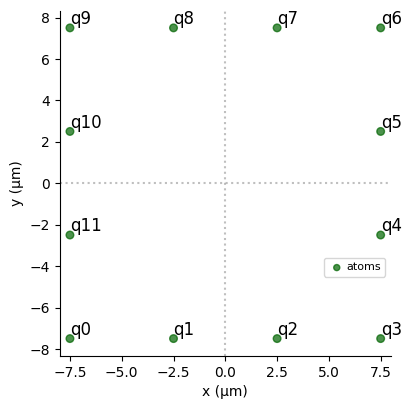

In [62]:
R_interatomic = 5  # µm

N_side = 4
coords = (
    [R_interatomic * np.r_[x, 0] for x in range(N_side - 1)]
    + [R_interatomic * np.r_[N_side - 1, y] for y in range(N_side - 1)]
    + [
        R_interatomic * np.r_[N_side - 1 - x, N_side - 1]
        for x in range(N_side - 1)
    ]
    + [R_interatomic * np.r_[0, N_side - 1 - y] for y in range(N_side - 1)]
)
reg = Register.from_coordinates(coords, prefix="q")
N = len(coords)
reg.draw()

In [63]:
# Let’s check that this register matches with the device’s constraints by initializing the Sequence:

seq = Sequence(reg, device)

The channel needed to prepare an AFM state is the Rydberg.Global channel. Let’s declare this channel in the Sequence,

In [64]:
T = 1000  # in µs

We are going to use a Pulse composed of Interpolated Waveforms to define the evolution of 
 and 
 along time. The first parameter to define is the duration of the pulse, 
:

In [65]:
seq.declare_channel("ising", "rydberg_global")

Let s define the 2m parameters we talked about. We start by initializing randomly the values for these  parameters, within the specifications of the declared Rydberg.Global channel.

In [66]:
# Size of the parameter space
m = 3

# Amp and detuning must respect the channel's specifications
tol = 1e-6  # within a certain tolerance

max_amp = seq.declared_channels["ising"].max_amp * (1 - tol)
Omega_max = min(max_amp, device.rabi_from_blockade(1.2 * R_interatomic))

U = 2 * Omega_max
max_det = seq.declared_channels["ising"].max_abs_detuning * (1 - tol)
delta_0 = -min(max_det, U)
delta_f = min(max_det, U)

# Random instance of the parameter space
amp_params = np.random.uniform(0, Omega_max, m)
det_params = np.random.uniform(delta_0, delta_f, m)

We define an interpolation function which takes as argument a set of parameters and returns the interpolated pulse associated. The interpolation is done through the InterpolatedWaveform class, which does monotonic cubic splines using PchipInterpolator by default.

Here, the starting and ending values of $\Omega$
 and  $\delta$
 are fixed such that $\Omega (0) = \Omega(T) = 0$
, 
 and $\delta(T) = \delta_f$
.


In [67]:
def create_interp_pulse(amp_params, det_params):
    return Pulse(
        InterpolatedWaveform(T, [1e-9, *amp_params, 1e-9]),
        InterpolatedWaveform(T, [delta_0, *det_params, delta_f]),
        0,
    )


Let’s use this function to add a pulse interpolating the randomly generated 
 parameters to the Sequence:

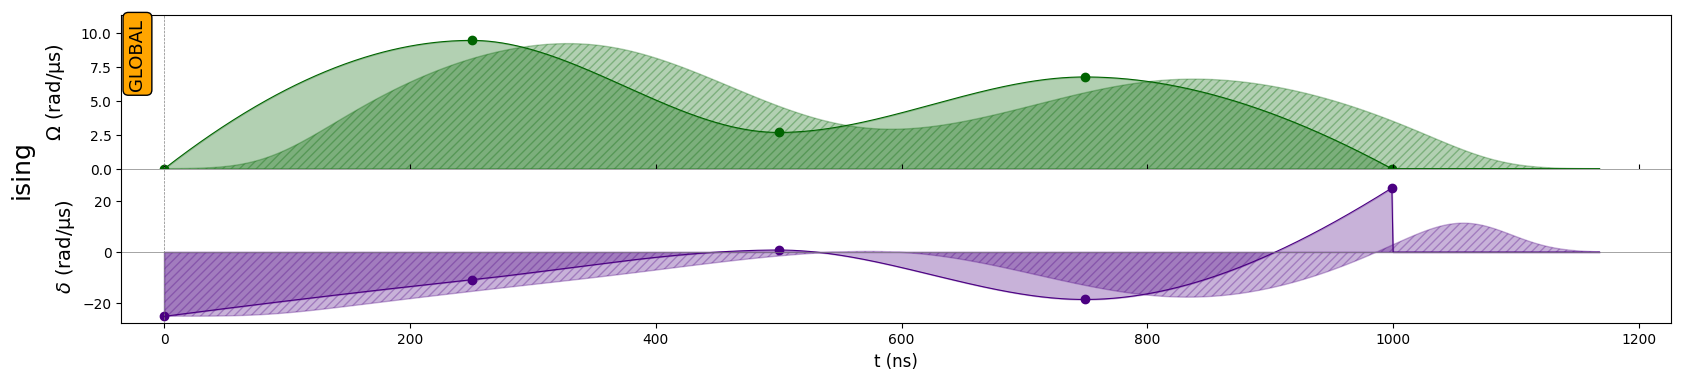

In [68]:
seq.add(create_interp_pulse(amp_params, det_params), "ising")
seq.draw()

2. Measurement and score function

Each Sequence generated with the 
 parameters has an associated result, obtained by measuring the state of the atoms at the end of the Sequence 
 times:

Counter({'000000000000': 138, '001000000000': 42, '000000010000': 39, '010000000000': 38, '000000000010': 36, '000100000000': 35, '100000000000': 31, '000000001000': 31, '000000000001': 30, '000000000100': 27, '000000100000': 27, '000010000000': 26, '000001000000': 25, '100000100000': 13, '000001001000': 11, '000001010000': 10, '000000010010': 10, '000100000001': 10, '010001000000': 9, '000001000100': 9, '000000010001': 9, '001000010000': 9, '100100000000': 9, '001000000010': 9, '010000001000': 9, '010010000000': 8, '100000010000': 8, '000010100000': 7, '001000000100': 7, '100000001000': 7, '000100000100': 7, '000100000010': 7, '100001000000': 7, '010000100000': 7, '001010000000': 6, '001000000001': 6, '010000000100': 6, '001000001000': 6, '000000010100': 6, '000001000010': 6, '001001000000': 6, '000010000100': 6, '101000000000': 6, '000101000000': 6, '000100010000': 6, '000000001010': 5, '000000100010': 5, '000000100001': 5, '000100001000': 5, '100010000000': 5, '000000001001': 5, '00

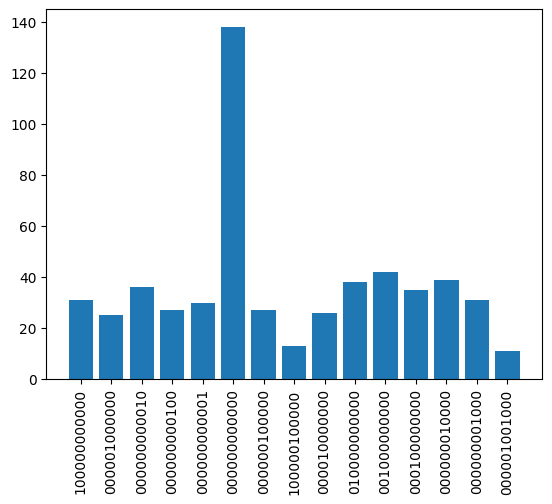

In [69]:
N_samples = 1000
simul = QutipBackendV2(seq)
results = simul.run()
final_state = results.final_state
counts = final_state.sample(num_shots=N_samples)
print(counts)
# Let's plot the histogram associated to the measurements
# Let's select only the states that are measured more than 10 times
most_freq = {k: v for k, v in counts.items() if v > 10}
plt.bar(list(most_freq.keys()), list(most_freq.values()))
plt.xticks(rotation="vertical")
plt.show()

The optimisation algorithm will browse the parameter space in search of an optimal shape of the pulse. In order to do so, we need to assign a score to each set of parameters based on the results we obtain at the end of the Sequence.

With the optimization algorithm set to look for minimum, the AFM state should have a score of 0 and all other states strictly positive score. 

As mentionned before, the score will be defined based on the Néel Structure Factor: $$\begin{split}S_{\text{Néel}}=4 \times \sum_{\substack{1\le k, l\le N\\ (k,l) \neq (0,0)}} (-1)^{|k|+|l|} g^{(2)}(k,l)\end{split}$$

Where g is the spin-spin correlation function:
$$g^{(2)}(k,l)= \frac{1}{N_{k,l}}\sum_{(i,j) = (kR,lR)} \left[ \langle n_i n_j \rangle - \langle n_i \rangle \langle n_j \rangle \right]$$

More on why this function is chosen: https://journals.aps.org/prx/abstract/10.1103/PhysRevX.8.021070

In [70]:
# here we only define the function

def occupation(j, N):
    up = qutip.basis(2, 0, dtype="CSR")
    prod = [qutip.qeye(2, dtype="CSR") for _ in range(N)]
    prod[j] = up * up.dag()
    return qutip.tensor(prod)


def get_corr_pairs(k, N):
    corr_pairs = [[i, (i + k) % N] for i in range(N)]
    return corr_pairs


def get_corr_function(k, N, state):
    corr_pairs = get_corr_pairs(k, N)
    operators = [occupation(j, N) for j in range(N)]
    covariance = 0
    for qi, qj in corr_pairs:
        covariance += qutip.expect(operators[qi] * operators[qj], state)
        covariance -= qutip.expect(operators[qi], state) * qutip.expect(
            operators[qj], state
        )
    return covariance / len(corr_pairs)


def get_neel_structure_factor(reg, state):
    N = len(reg.qubits)
    st_fac = 0
    for k in range(-N // 2, N // 2 + 1):
        kk = np.abs(k)
        st_fac += 4 * (-1) ** kk * get_corr_function(k, N, state)
    return st_fac

Since our optimizer will minimize the score function, we take $1-S_{Néel}$
 for the score. The score function is then a function that:

-takes as input the 2m
     parameters describing $\Omega$
 and $\delta$
;

-generates the Sequence associated with these 
 parameters;

-submits this Sequence to a backend (here, we take QutipBackendV2);

-computes $1-S_{Néel}$
 from the obtained results.

In [71]:
def score(params):
    """Computes the score associated with a set of parameters."""
    seq = Sequence(reg, AnalogDevice)
    seq.declare_channel("ising", "rydberg_global")
    seq.add(create_interp_pulse(params[:m], params[m:]), "ising")

    simul = QutipBackendV2(seq)
    results = simul.run()

    sampling = results.final_state.sample(num_shots=N_samples)
    sampled_state = sum(
        [
            np.sqrt(sampling[k] / N_samples) * qutip.ket(k, dtype="CSR")
            for k in sampling.keys()
        ]
    )

    F = get_neel_structure_factor(reg, sampled_state) / S_max

    return 1 - F

For the Sequence with random parameters, the score is:



In [72]:
score(np.r_[amp_params, det_params])

0.9556038205128206

3. Optimisation


We are probing the 2m parameter space cons a 
-dimensional hyper-rectangle $[0,\Omega_{max}]^m\times[\delta_0,\delta_f]^m$
 with $n_r$
 training points and a total of $n_c$
 probing points. The optimisation is achieved using gp_minimize from the module scikit-optimize.

In [73]:
bounds = [(0.0, Omega_max)] * m + [(delta_0, delta_f)] * m

n_r = 30
n_c = 120

RESULT = gp_minimize(
    score, bounds, n_random_starts=n_r, n_calls=n_c, verbose=False
)

To ensure that the optimisation is well-designed, i.e. enough but not too many steps, we plot its performance in terms of the minimum score found after 
 to the score function.



In [74]:
def sort_improv(RESULT):
    score_vals = RESULT.func_vals
    min = score_vals[0]
    score_list = []
    for s in score_vals:
        if s < min:
            min = s
            score_list.append(min)
        else:
            score_list.append(min)
    return score_list

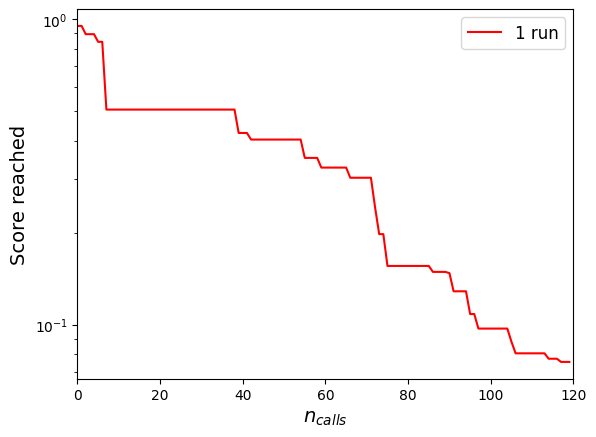

In [75]:
fig = plt.figure()
plt.semilogy(range(n_c), sort_improv(RESULT), "r-")
plt.xlabel(r"$n_{calls}$", fontsize=14)
plt.ylabel("Score reached", fontsize=14)
plt.legend(["1 run"], fontsize=12)
plt.xlim(0, n_c)
plt.show()

An interpolated pulse is produced based on the optimised parameters RESULT.x and then added to a new sequence.



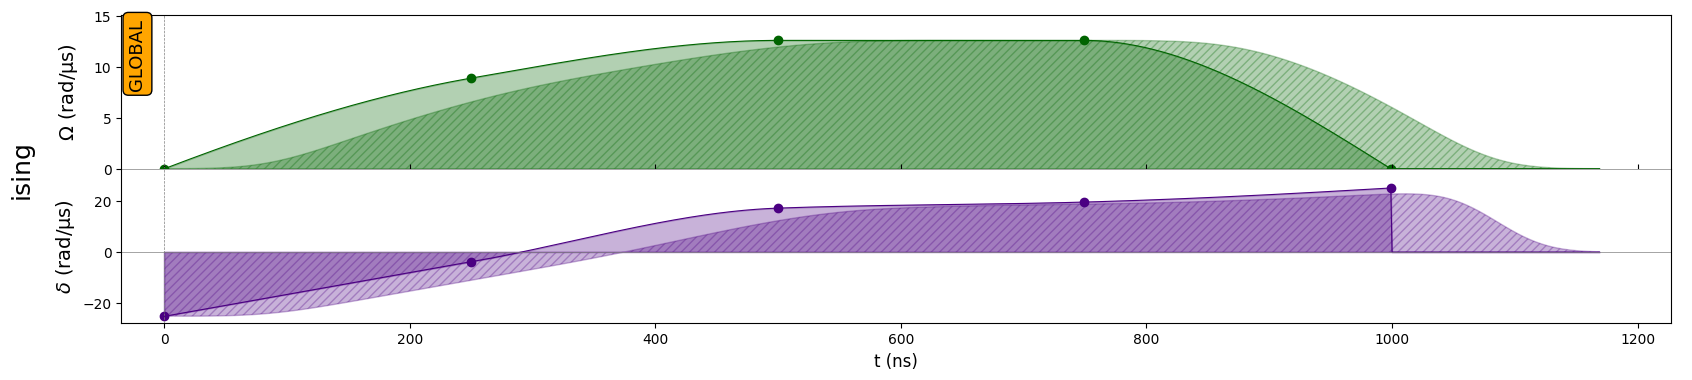

In [76]:
seq = Sequence(reg, AnalogDevice)
seq.declare_channel("ising", "rydberg_global")
P = create_interp_pulse(RESULT.x[:m], RESULT.x[m:])
seq.add(P, "ising")
seq.draw()

Most frequent bitstrings measured (1000 measurements) {'010101010101': 413, '101010101010': 457, '010100010101': 11, '000101010101': 11}
S_Neel (final_sampled) = 12.031


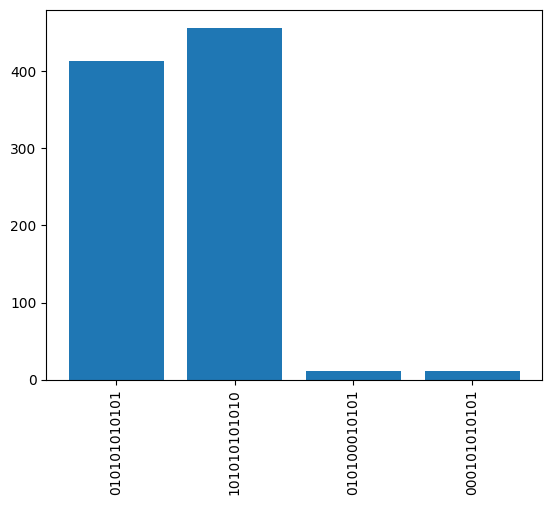

In [77]:
simul = QutipBackendV2(seq)
results = simul.run()
sampling = results.final_state.sample(num_shots=N_samples)
sampled_state = sum(
    [np.sqrt(sampling[k] / 1000) * qutip.ket(k) for k in sampling.keys()]
)

s_neel_sampled = np.round(get_neel_structure_factor(reg, sampled_state), 3)
most_freq = {k: v for k, v in sampling.items() if v > 10}

print(
    f"Most frequent bitstrings measured ({N_samples} measurements)", most_freq
)
print(f"S_Neel (final_sampled) = {s_neel_sampled}")
plt.bar(list(most_freq.keys()), list(most_freq.values()))
plt.xticks(rotation="vertical")
plt.show()

The final state is an Anti-Ferromagnetic state, as a superposition of the two checkerboard states, $\left|010101010101\right>$
 and $\left|101010101010\right>$
 !